# DQN — LunarLander-v2 (2000 Episodes)

A complete, corrected Double DQN implementation with:
- **Double DQN** — decouples action selection from Q-value estimation (fixes overestimation)
- **Large replay buffer** (100k) with minimum warmup before training starts
- **Huber loss** instead of MSE — bounds large TD errors
- **Gradient clipping** for stability
- **Correct epsilon decay** — per episode, calibrated to 2000-episode schedule
- **Soft target network update** (Polyak averaging) as an alternative to hard copy
- **Rolling reward tracking** with convergence check (reward >= 200)

In [1]:
# Imports
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import glob
from collections import deque
from IPython.display import Video, display

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Hyperparameters
ENV_NAME        = 'LunarLander-v2'
STATE_SIZE      = 8
ACTION_SIZE     = 4
NUM_ENVS        = 4
NUM_EPISODES    = 2000
MAX_STEPS       = 1000

LEARNING_RATE   = 5e-4
GAMMA           = 0.99
BATCH_SIZE      = 128
BUFFER_CAPACITY = 100_000   # fix: was 5000 — far too small
WARMUP_STEPS    = 2_000     # steps before any training update
UPDATE_EVERY    = 4         # policy update every N env steps
TARGET_SYNC     = 500       # sync target net every N policy updates
MAX_GRAD_NORM   = 10.0

# Epsilon schedule — per episode, not per update (fix: was decaying 4x too fast)
EPSILON_START   = 1.0
EPSILON_END     = 0.01
EPSILON_DECAY   = 0.998     # reaches ~0.02 by episode 1800

SOLVE_REWARD    = 200
SOLVE_WINDOW    = 100

print('Hyperparameters set.')

Hyperparameters set.


In [3]:
# Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_size=STATE_SIZE, action_size=ACTION_SIZE, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),     nn.ReLU(),
            nn.Linear(hidden, action_size)
        )
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.net(x)


policy_net = QNetwork().to(device)
target_net = QNetwork().to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)

print(policy_net)
print(f'Total parameters: {sum(p.numel() for p in policy_net.parameters()):,}')

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)
Total parameters: 69,124


In [4]:
# Replay Buffer — pre-allocated numpy arrays (faster than Python lists)
class ReplayBuffer:
    def __init__(self, capacity=BUFFER_CAPACITY, state_size=STATE_SIZE):
        self.capacity = capacity
        self.ptr      = 0
        self.size     = 0
        self.states      = np.zeros((capacity, state_size), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_size), dtype=np.float32)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        self.states[self.ptr]      = state
        self.next_states[self.ptr] = next_state
        self.actions[self.ptr]     = action
        self.rewards[self.ptr]     = reward
        self.dones[self.ptr]       = float(done)
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size=BATCH_SIZE):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.tensor(self.states[idx],      device=device),
            torch.tensor(self.actions[idx],     device=device),
            torch.tensor(self.rewards[idx],     device=device),
            torch.tensor(self.next_states[idx], device=device),
            torch.tensor(self.dones[idx],       device=device),
        )

    def __len__(self):
        return self.size


replay_buffer = ReplayBuffer()
print(f'Buffer ready. Capacity: {BUFFER_CAPACITY:,} | Warmup: {WARMUP_STEPS:,} steps')

Buffer ready. Capacity: 100,000 | Warmup: 2,000 steps


In [5]:
# Epsilon-greedy selection
def select_action(state_np, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(ACTION_SIZE)
    state_t = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return policy_net(state_t).argmax(dim=1).item()


# Double DQN update
def dqn_update():
    states, actions, rewards, next_states, dones = replay_buffer.sample()

    current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        # Double DQN: policy_net selects action, target_net scores it
        best_next_actions = policy_net(next_states).argmax(dim=1, keepdim=True)
        next_q    = target_net(next_states).gather(1, best_next_actions).squeeze(1)
        target_q  = rewards + (1.0 - dones) * GAMMA * next_q

    loss = F.huber_loss(current_q, target_q)   # fix: was MSE

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), MAX_GRAD_NORM)
    optimizer.step()

    return loss.item()


# Target network sync (hard or soft)
def sync_target(tau=1.0):
    for tp, pp in zip(target_net.parameters(), policy_net.parameters()):
        tp.data.copy_(tau * pp.data + (1.0 - tau) * tp.data)


print('Double DQN helpers defined.')

Double DQN helpers defined.


In [6]:
# Training loop
def dqn_train(num_episodes=NUM_EPISODES):
    env = gym.vector.make(ENV_NAME, num_envs=NUM_ENVS)
    env.reset(seed=SEED)

    rewards_history = []
    steps_history   = []
    loss_history    = []
    rolling_rewards = deque(maxlen=SOLVE_WINDOW)

    epsilon      = EPSILON_START
    total_steps  = 0
    update_count = 0
    completed    = 0
    solved_at    = None

    env_rewards = np.zeros(NUM_ENVS)
    env_steps   = np.zeros(NUM_ENVS, dtype=int)

    obs, _ = env.reset()

    while completed < num_episodes:
        actions = [select_action(obs[i], epsilon) for i in range(NUM_ENVS)]
        next_obs, rewards, terminated, truncated, _ = env.step(actions)
        dones = terminated | truncated

        for i in range(NUM_ENVS):
            replay_buffer.push(obs[i], actions[i], rewards[i], next_obs[i], dones[i])
            env_rewards[i] += rewards[i]
            env_steps[i]   += 1

        total_steps += NUM_ENVS
        obs = next_obs

        # Policy update after warmup
        if len(replay_buffer) >= WARMUP_STEPS and total_steps % UPDATE_EVERY == 0:
            loss = dqn_update()
            update_count += 1
            loss_history.append(loss)
            if update_count % TARGET_SYNC == 0:
                sync_target()

        # Episode completion
        for i in range(NUM_ENVS):
            if dones[i] and completed < num_episodes:
                completed += 1
                epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)  # fix: per episode

                rolling_rewards.append(env_rewards[i])
                rewards_history.append(env_rewards[i])
                steps_history.append(int(env_steps[i]))

                roll_mean = np.mean(rolling_rewards)
                if completed % 50 == 0:
                    buf_pct = 100 * len(replay_buffer) / BUFFER_CAPACITY
                    print(f'Ep {completed:4d} | steps {env_steps[i]:4d} | '
                          f'reward {env_rewards[i]:8.2f} | '
                          f'rolling{SOLVE_WINDOW} {roll_mean:7.2f} | '
                          f'eps {epsilon:.3f} | buf {buf_pct:.0f}%')

                if (solved_at is None
                        and len(rolling_rewards) == SOLVE_WINDOW
                        and roll_mean >= SOLVE_REWARD):
                    solved_at = completed
                    print(f'\n*** SOLVED at episode {solved_at} '
                          f'(rolling mean = {roll_mean:.2f}) ***\n')

                env_rewards[i] = 0
                env_steps[i]   = 0

    env.close()
    print(f'\nTraining complete. Total env steps: {total_steps:,} | Updates: {update_count:,}')
    if solved_at:
        print(f'Environment solved at episode {solved_at}.')
    else:
        rm = np.mean(rolling_rewards) if rolling_rewards else float('nan')
        print(f'Final rolling mean: {rm:.2f} (threshold {SOLVE_REWARD}).')

    return rewards_history, steps_history, loss_history


print('Training loop defined.')

Training loop defined.


In [7]:
# Run training
print('=== Double DQN — LunarLander-v2 (2000 episodes) ===')
print(f'Replay buffer warmup: {WARMUP_STEPS:,} steps before first update.\n')
train_rewards, train_steps, train_losses = dqn_train(NUM_EPISODES)

=== Double DQN — LunarLander-v2 (2000 episodes) ===
Replay buffer warmup: 2,000 steps before first update.



c:\Users\ninaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\vector\__init__.py:53: UserWarning: WARN: `gymnasium.vector.make(...)` is deprecated and will be replaced by `gymnasium.make_vec(...)` in v1.0
  gym.logger.warn(


Ep   50 | steps   97 | reward   -78.56 | rolling100 -170.93 | eps 0.905 | buf 5%
Ep  100 | steps  173 | reward   -37.56 | rolling100 -151.10 | eps 0.819 | buf 10%
Ep  150 | steps  137 | reward  -104.21 | rolling100 -119.59 | eps 0.741 | buf 16%
Ep  200 | steps  125 | reward  -180.59 | rolling100  -92.12 | eps 0.670 | buf 23%
Ep  250 | steps  114 | reward   -79.63 | rolling100  -60.92 | eps 0.606 | buf 31%
Ep  300 | steps  114 | reward   -61.10 | rolling100  -44.00 | eps 0.548 | buf 39%
Ep  350 | steps  275 | reward  -245.90 | rolling100  -34.99 | eps 0.496 | buf 57%
Ep  400 | steps  115 | reward   -16.70 | rolling100  -17.22 | eps 0.449 | buf 71%
Ep  450 | steps   73 | reward   -16.93 | rolling100   -8.07 | eps 0.406 | buf 84%
Ep  500 | steps  103 | reward    22.31 | rolling100   -0.92 | eps 0.368 | buf 95%
Ep  550 | steps   93 | reward    40.91 | rolling100   16.94 | eps 0.333 | buf 100%
Ep  600 | steps 1000 | reward   107.45 | rolling100   35.71 | eps 0.301 | buf 100%
Ep  650 | steps

In [8]:
# Save checkpoint
torch.save(policy_net.state_dict(), 'dqn_lunarlander.pt')
print('Model saved to dqn_lunarlander.pt')

Model saved to dqn_lunarlander.pt


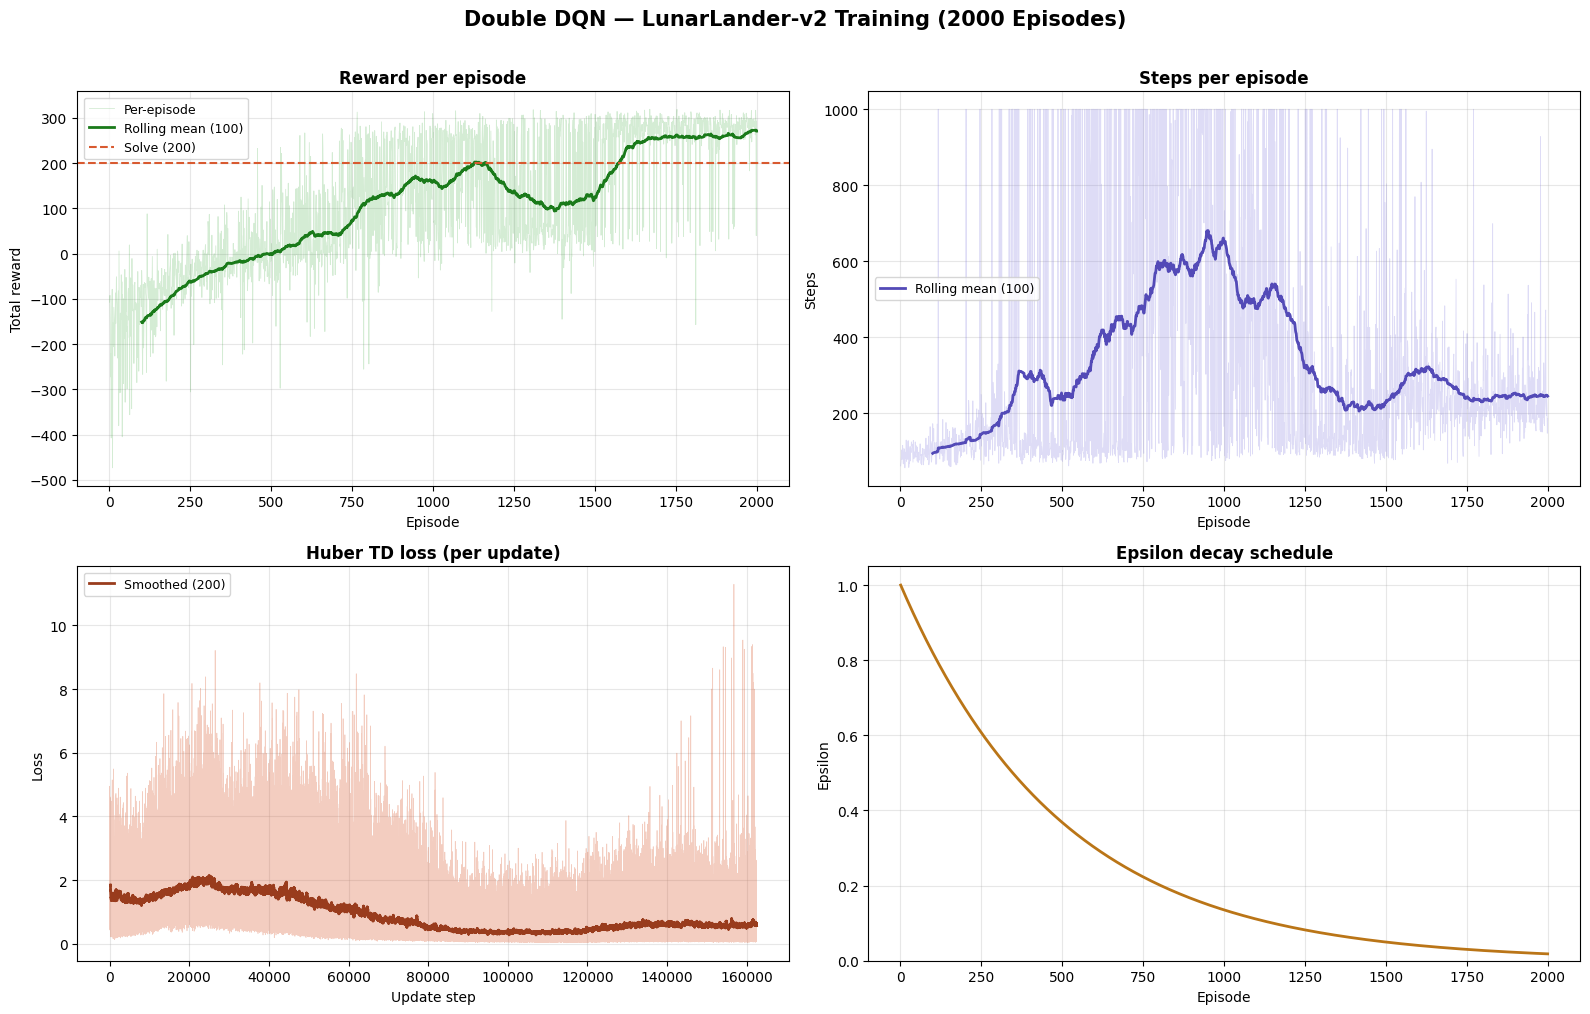

Curves saved to dqn_training_curves.png


In [9]:
# Plot training curves
rewards_arr = np.array(train_rewards)
episodes    = np.arange(1, len(rewards_arr) + 1)

def rolling_mean(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Double DQN — LunarLander-v2 Training (2000 Episodes)',
             fontsize=15, fontweight='bold', y=1.01)

# Reward
ax = axes[0, 0]
ax.plot(episodes, rewards_arr, alpha=0.2, color='#2ca02c', linewidth=0.6, label='Per-episode')
if len(rewards_arr) >= 100:
    rm = rolling_mean(rewards_arr, 100)
    ax.plot(np.arange(100, len(rewards_arr) + 1), rm, color='#1a7a1a', linewidth=2, label='Rolling mean (100)')
ax.axhline(SOLVE_REWARD, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Solve ({SOLVE_REWARD})')
ax.set_title('Reward per episode', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Steps
ax = axes[0, 1]
ax.plot(episodes, train_steps, alpha=0.25, color='#7F77DD', linewidth=0.6)
if len(train_steps) >= 100:
    ax.plot(np.arange(100, len(train_steps) + 1),
            rolling_mean(np.array(train_steps), 100),
            color='#534AB7', linewidth=2, label='Rolling mean (100)')
ax.set_title('Steps per episode', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# TD Loss
ax = axes[1, 0]
if train_losses:
    upd = np.arange(1, len(train_losses) + 1)
    ax.plot(upd, train_losses, alpha=0.3, color='#D85A30', linewidth=0.5)
    if len(train_losses) >= 200:
        smooth = rolling_mean(np.array(train_losses), 200)
        ax.plot(np.arange(200, len(train_losses) + 1), smooth, color='#993C1D', linewidth=2, label='Smoothed (200)')
    ax.set_title('Huber TD loss (per update)', fontweight='bold')
    ax.set_xlabel('Update step'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Epsilon schedule
ax = axes[1, 1]
eps_curve = [max(EPSILON_END, EPSILON_START * (EPSILON_DECAY ** ep)) for ep in range(NUM_EPISODES)]
ax.plot(np.arange(1, NUM_EPISODES + 1), eps_curve, color='#BA7517', linewidth=2)
ax.set_title('Epsilon decay schedule', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Epsilon')
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curves saved to dqn_training_curves.png')

In [10]:
# Summary statistics
r = np.array(train_rewards)
print('=== Training Summary ===')
print(f'Episodes trained      : {len(r)}')
print(f'Mean reward           : {r.mean():.2f}')
print(f'Std reward            : {r.std():.2f}')
print(f'Best episode          : {r.max():.2f}')
print(f'Worst episode         : {r.min():.2f}')
print(f'Replay buffer filled  : {len(replay_buffer):,} / {BUFFER_CAPACITY:,}')
if len(r) >= SOLVE_WINDOW:
    final_mean = r[-SOLVE_WINDOW:].mean()
    status = 'SOLVED' if final_mean >= SOLVE_REWARD else 'not yet solved'
    print(f'Final {SOLVE_WINDOW}-ep mean    : {final_mean:.2f} ({status})')

=== Training Summary ===
Episodes trained      : 2000
Mean reward           : 108.45
Std reward            : 149.88
Best episode          : 318.85
Worst episode         : -473.41
Replay buffer filled  : 100,000 / 100,000
Final 100-ep mean    : 270.57 (SOLVED)


In [11]:
# Record video of trained agent
def record_video(net, folder='./videos', tag='dqn-agent'):
    env = gym.make(ENV_NAME, render_mode='rgb_array')
    env = gym.wrappers.RecordVideo(env, folder, episode_trigger=lambda e: True, name_prefix=tag)
    net.eval()
    with torch.no_grad():
        obs, _ = env.reset(seed=0)
        total_reward, steps = 0, 0
        for _ in range(MAX_STEPS):
            state_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            action  = net(state_t).argmax(dim=1).item()
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward; steps += 1
            if terminated or truncated:
                break
    env.close()
    net.train()
    print(f'Recorded: {steps} steps, reward {total_reward:.2f}')
    files = sorted(glob.glob(f'{folder}/{tag}*.mp4'))
    if files:
        display(Video(files[-1], embed=True, width=600))


print('Recording video of trained DQN agent...')
record_video(policy_net)

Recording video of trained DQN agent...


c:\Users\ninaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at e:\University 5B\CS AI\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Moviepy - Building video e:\University 5B\CS AI\videos\dqn-agent-episode-0.mp4.
Moviepy - Writing video e:\University 5B\CS AI\videos\dqn-agent-episode-0.mp4



Moviepy - Done !
Moviepy - video ready e:\University 5B\CS AI\videos\dqn-agent-episode-0.mp4
Recorded: 166 steps, reward 314.28


In [12]:
# Evaluation — greedy, 20 episodes
def evaluate(net, num_episodes=20, max_steps=MAX_STEPS):
    env = gym.make(ENV_NAME)
    rewards, steps_list = [], []
    net.eval()
    with torch.no_grad():
        for ep in range(num_episodes):
            obs, _ = env.reset(seed=ep)
            total, steps = 0, 0
            for _ in range(max_steps):
                state_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                action  = net(state_t).argmax(dim=1).item()
                obs, reward, terminated, truncated, _ = env.step(action)
                total += reward; steps += 1
                if terminated or truncated:
                    break
            rewards.append(total)
            steps_list.append(steps)
            print(f'Eval ep {ep+1:3d}: {steps:4d} steps, reward {total:8.2f}')
    env.close()
    net.train()
    print(f'\nEval mean: {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}')
    return rewards, steps_list


print('=== Evaluation (20 episodes, greedy) ===')
eval_rewards, eval_steps = evaluate(policy_net, num_episodes=20)

=== Evaluation (20 episodes, greedy) ===
Eval ep   1:  166 steps, reward   314.28
Eval ep   2:  197 steps, reward   275.60
Eval ep   3:  165 steps, reward   258.86
Eval ep   4:  163 steps, reward   251.52
Eval ep   5:  922 steps, reward   249.24
Eval ep   6:  182 steps, reward   284.16
Eval ep   7:  284 steps, reward   318.51
Eval ep   8:  169 steps, reward   270.92
Eval ep   9:  566 steps, reward   211.99
Eval ep  10:  253 steps, reward   294.20
Eval ep  11:  323 steps, reward   264.22
Eval ep  12:  157 steps, reward   275.91
Eval ep  13:  201 steps, reward   298.50
Eval ep  14:  411 steps, reward   265.78
Eval ep  15:  171 steps, reward   271.49
Eval ep  16:  171 steps, reward   287.96
Eval ep  17: 1000 steps, reward   153.73
Eval ep  18:  332 steps, reward   286.28
Eval ep  19:  151 steps, reward    36.66
Eval ep  20:  157 steps, reward   254.48

Eval mean: 256.21 +/- 61.36
